In [1]:
import numpy as np # 
from numpy.typing import NDArray 
from numpy import complexfloating as complex_t   
from numpy import floating as real_t                 
import matplotlib.pyplot as plt    
from modules_rel import* 
from modules_for_Bcomplex import* 
from modules_hyper import*

 
# needed natural constants
ij=complex(0.0,1.0)
eV = 27.211384 
atto = 24.18884326505
cpeed=137.035999074 
cm2=0.52917721092**2*100.0 
cross_const=(4.0/3.0)/cpeed*np.pi*cm2
# Nuclear charge 
Zcharge=1.0

# data folder
data_folder = "./outputRa/"

In [2]:
def read_knot_points(file:str) -> NDArray[np.complex128]:
    """
    Reads the knot point sequence from the given file.

    Args:
        file - path to the file.
    
    Returns:
        knots - array with the knot points.
    """

    knots_raw = np.loadtxt(file)

    knots = np.zeros(knots_raw.shape[0], dtype=np.complex128)

    knots = knots_raw[:, 0] + 1j * knots_raw[:, 1]

    return knots



In [3]:
knots_file = data_folder + "grid_vec.dat"

knots = read_knot_points(knots_file)

In [4]:
def get_knots_f_g(k_order_f: int, k_order_g: int, knots: NDArray[np.complex128]) -> tuple[NDArray[np.complex128], NDArray[np.complex128]]:
    """
    Takes a sequence of knot points and extarcts (separates) the knot point for the large and small
    components.

    Args:
        k_order_f - order of the B-splines for the large component.
        k_order_g - order of the B-splines for the small component.
        knots - a sequence of the knot points from Relcode.
    
    Returns:
        knots_f, knots_g - knot points for the large and small components respectively.
    """

    if k_order_f < k_order_g:
        knots_g = knots.copy()
        k_diff = k_order_g - k_order_f
        knots_f = knots[k_diff:-k_diff].copy()

    elif k_order_f > k_order_g:
        knots_f = knots.copy()
        k_diff = k_order_f - k_order_g
        knots_g = knots[k_diff:-k_diff].copy()

    else: # k_order_f == k_order_g
        knots_f = knots.copy()
        knots_g = knots.copy()

    return knots_f, knots_g

In [5]:
k_order_f = 7
k_order_g = 8

knots_f, knots_g = get_knots_f_g(k_order_f, k_order_g, knots)

n_knots_f = knots_f.shape[0]
n_knots_g = knots_g.shape[0]

print(knots_f.shape)
print(knots_g.shape)

(275,)
(277,)


In [6]:
# g_grid - Gaussian grid
# g_weights - Gaussian weights
# g_num_between - number of Gaussian points between each pair of knot points

g_grid_f, g_weights_f, g_num_between_f = getgaussiangrid(knots_f, n_knots_f, k_order_f, 0)
g_grid_g, g_weights_g, g_num_between_g = getgaussiangrid(knots_g, n_knots_g, k_order_g, 0)

print(g_grid_f.shape)
print(g_weights_g.shape)


this is the gaussian grid, with 8  points between each  knot point
this is the gaussian grid, with 9  points between each  knot point
(2096,)
(2358,)


In [7]:
def read_bspline_coeffs(file: str) -> NDArray[real_t]:
    """
    Reads the b spline coefficients from the given file.

    Args:
        file - path to the file.
    
    Returns:
        coeffs - array with the coefficients.
    """

    coeffs = np.loadtxt(file)

    return coeffs


def split_bspline_coeffs_by_channels(coeffs: NDArray[real_t], n_channels: int) -> NDArray[real_t]:
    """
    Splits the given bspline coefficients by the channels.

    Args:
        coeffs - bspline coefficients.
        n_channels - number of channels.

    Returns:
        coeffs_split - coefficients array split by channels.
    """

    assert (
        coeffs.size % n_channels == 0
    ), f"The coefficent array of size {coeffs.size} can not be split by {n_channels} channels!"

    channel_size = int(coeffs.size / n_channels) # size of the coefficients array for one channel

    coeffs_split = np.zeros((channel_size, n_channels), dtype=coeffs.dtype)

    for i in range(n_channels):
        coeffs_split[:, i] = coeffs[i*channel_size:(i+1)*channel_size]

    return coeffs_split


In [8]:
# work with a p_3/2 hole

# read the bspline coefficients
file_coeffs_pw_f_9_imag = data_folder + "pert_-2_5/pert_wave_BSp_Fi_9.dat"
coeffs_pw_f_9_imag_raw = read_bspline_coeffs(file_coeffs_pw_f_9_imag)
coeffs_pw_f_9_imag = split_bspline_coeffs_by_channels(coeffs_pw_f_9_imag_raw, 3)

file_coeffs_pw_f_9_real = data_folder + "pert_-2_5/pert_wave_BSp_Fr_9.dat"
coeffs_pw_f_9_real_raw = read_bspline_coeffs(file_coeffs_pw_f_9_real)
coeffs_pw_f_9_real = split_bspline_coeffs_by_channels(coeffs_pw_f_9_real_raw, 3)

# transform into the radial representation
pw_f_9_imag_s1 = getfunc_in_r(n_knots_f, k_order_f, knots_f, coeffs_pw_f_9_imag[:, 0], g_grid_f)
pw_f_9_real_s1 = getfunc_in_r(n_knots_f, k_order_f, knots_f, coeffs_pw_f_9_real[:, 0], g_grid_f)

pw_f_9_imag_d3 = getfunc_in_r(n_knots_f, k_order_f, knots_f, coeffs_pw_f_9_imag[:, 1], g_grid_f)
pw_f_9_real_d3 = getfunc_in_r(n_knots_f, k_order_f, knots_f, coeffs_pw_f_9_real[:, 1], g_grid_f)

pw_f_9_imag_d5 = getfunc_in_r(n_knots_f, k_order_f, knots_f, coeffs_pw_f_9_imag[:, 2], g_grid_f)
pw_f_9_real_d5 = getfunc_in_r(n_knots_f, k_order_f, knots_f, coeffs_pw_f_9_real[:, 2], g_grid_f)

In [9]:
coeffs_pw_f_9_real.shape

(266, 3)

In [10]:
file_coeffs_pw_g_9_imag = data_folder + "pert_-2_5/pert_wave_BSp_Gi_9.dat"
coeffs_pw_g_9_imag_raw = read_bspline_coeffs(file_coeffs_pw_g_9_imag)
coeffs_pw_g_9_imag = split_bspline_coeffs_by_channels(coeffs_pw_g_9_imag_raw, 3)

coeffs_pw_g_9_imag.shape

(267, 3)

Text(0.5, 1.0, 'd_{5/2}')

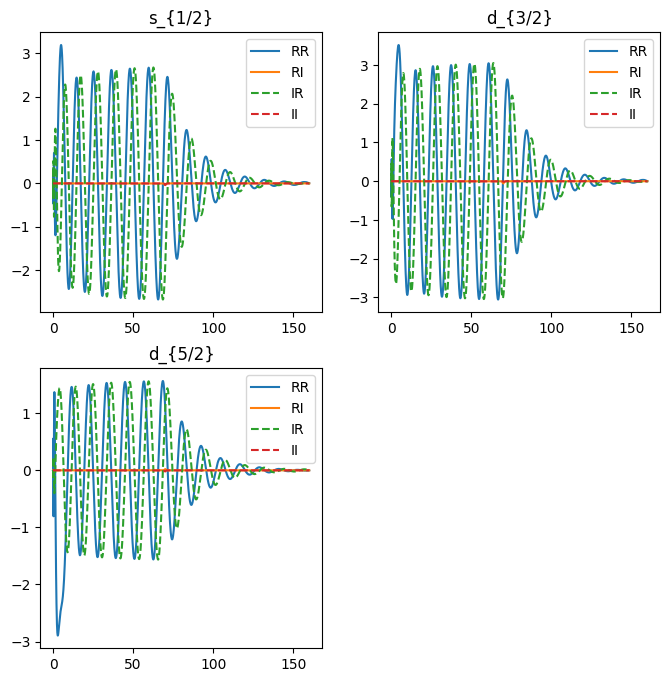

In [11]:
plt.figure(figsize=(8, 8))

plt.subplot(2, 2, 1)
plt.plot(np.real(g_grid_f), np.real(pw_f_9_real_s1), "-", label="RR")
plt.plot(np.real(g_grid_f), np.imag(pw_f_9_real_s1), "-", label="RI")
plt.plot(np.real(g_grid_f), np.real(pw_f_9_imag_s1), "--", label="IR")
plt.plot(np.real(g_grid_f), np.imag(pw_f_9_imag_s1), "--", label="II")
plt.legend()
plt.title("s_{1/2}")

plt.subplot(2, 2, 2)
plt.plot(np.real(g_grid_f), np.real(pw_f_9_real_d3), "-", label="RR")
plt.plot(np.real(g_grid_f), np.imag(pw_f_9_real_d3), "-", label="RI")
plt.plot(np.real(g_grid_f), np.real(pw_f_9_imag_d3), "--", label="IR")
plt.plot(np.real(g_grid_f), np.imag(pw_f_9_imag_d3), "--", label="II")
plt.legend()
plt.title("d_{3/2}")

plt.subplot(2, 2, 3)
plt.plot(np.real(g_grid_f), np.real(pw_f_9_real_d5), "-", label="RR")
plt.plot(np.real(g_grid_f), np.imag(pw_f_9_real_d5), "-", label="RI")
plt.plot(np.real(g_grid_f), np.real(pw_f_9_imag_d5), "--", label="IR")
plt.plot(np.real(g_grid_f), np.imag(pw_f_9_imag_d5), "--", label="II")
plt.legend()
plt.title("d_{5/2}")

C:\Users\shapo\AppData\Local\Temp\ipykernel_15452\2290288112.py:6: RuntimeWarning: divide by zero encountered in divide
  plt.plot(np.real(g_grid_f)[region_mask], np.abs(np.real(pw_f_9_real_s1) / np.imag(pw_f_9_real_s1))[region_mask], "-", label="RR / RI")
C:\Users\shapo\AppData\Local\Temp\ipykernel_15452\2290288112.py:7: RuntimeWarning: divide by zero encountered in divide
  plt.plot(np.real(g_grid_f)[region_mask], np.abs(np.real(pw_f_9_imag_s1) / np.imag(pw_f_9_imag_s1))[region_mask], "--", label="IR / II")
C:\Users\shapo\AppData\Local\Temp\ipykernel_15452\2290288112.py:13: RuntimeWarning: divide by zero encountered in divide
  plt.plot(np.real(g_grid_f)[region_mask], np.abs(np.real(pw_f_9_real_d3) / np.imag(pw_f_9_real_d3))[region_mask], "-", label="RR / RI")
C:\Users\shapo\AppData\Local\Temp\ipykernel_15452\2290288112.py:14: RuntimeWarning: divide by zero encountered in divide
  plt.plot(np.real(g_grid_f)[region_mask], np.abs(np.real(pw_f_9_imag_d3) / np.imag(pw_f_9_imag_d3))[regio

578234.3341056469
3513359.5572990584
1536081.0607511245
9300708.303228885
653055.2961253297
6905162.769835192


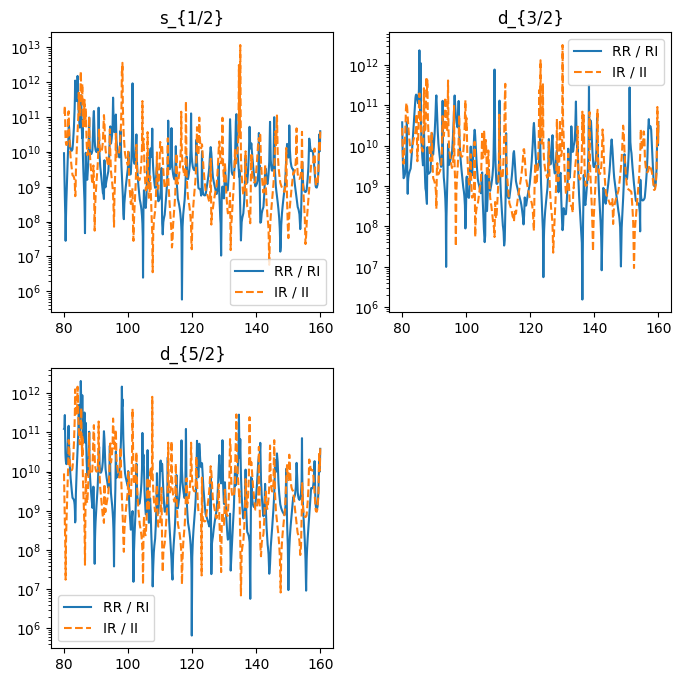

In [12]:
plt.figure(figsize=(8, 8))

region_mask = np.logical_and(np.real(g_grid_f) > 80, np.real(g_grid_f) < 160)

plt.subplot(2, 2, 1)
plt.plot(np.real(g_grid_f)[region_mask], np.abs(np.real(pw_f_9_real_s1) / np.imag(pw_f_9_real_s1))[region_mask], "-", label="RR / RI")
plt.plot(np.real(g_grid_f)[region_mask], np.abs(np.real(pw_f_9_imag_s1) / np.imag(pw_f_9_imag_s1))[region_mask], "--", label="IR / II")
plt.yscale("log")
plt.legend()
plt.title("s_{1/2}")

plt.subplot(2, 2, 2)
plt.plot(np.real(g_grid_f)[region_mask], np.abs(np.real(pw_f_9_real_d3) / np.imag(pw_f_9_real_d3))[region_mask], "-", label="RR / RI")
plt.plot(np.real(g_grid_f)[region_mask], np.abs(np.real(pw_f_9_imag_d3) / np.imag(pw_f_9_imag_d3))[region_mask], "--", label="IR / II")
plt.yscale("log")
plt.legend()
plt.title("d_{3/2}")

plt.subplot(2, 2, 3)
plt.plot(np.real(g_grid_f)[region_mask], np.abs(np.real(pw_f_9_real_d5) / np.imag(pw_f_9_real_d5))[region_mask], "-", label="RR / RI")
plt.plot(np.real(g_grid_f)[region_mask], np.abs(np.real(pw_f_9_imag_d5) / np.imag(pw_f_9_imag_d5))[region_mask], "--", label="IR / II")
plt.yscale("log")
plt.legend()
plt.title("d_{5/2}")


print(np.min(np.abs(np.real(pw_f_9_real_s1) / np.imag(pw_f_9_real_s1))[region_mask]))
print(np.min(np.abs(np.real(pw_f_9_imag_s1) / np.imag(pw_f_9_imag_s1))[region_mask]))

print(np.min(np.abs(np.real(pw_f_9_real_d3) / np.imag(pw_f_9_real_d3))[region_mask]))
print(np.min(np.abs(np.real(pw_f_9_imag_d3) / np.imag(pw_f_9_imag_d3))[region_mask]))

print(np.min(np.abs(np.real(pw_f_9_real_d5) / np.imag(pw_f_9_real_d5))[region_mask]))
print(np.min(np.abs(np.real(pw_f_9_imag_d5) / np.imag(pw_f_9_imag_d5))[region_mask]))

In [13]:
# NOTE since the radial represntations are complex numbers (WHY????) and their real parts 
# are dominating over imaginary parts by more than 10^5, the two reconstructions below give very
# close results
pw_f_9_s1 = pw_f_9_real_s1 + 1j * pw_f_9_imag_s1
pw_f_9_d3 = pw_f_9_real_d3 + 1j * pw_f_9_imag_d3
pw_f_9_d5 = pw_f_9_real_d5 + 1j * pw_f_9_imag_d5


pw_f_9_s1_way2 = np.real(pw_f_9_real_s1) + 1j * np.real(pw_f_9_imag_s1)
pw_f_9_d3_way2 = np.real(pw_f_9_real_d3) + 1j * np.real(pw_f_9_imag_d3)
pw_f_9_d5_way2 = np.real(pw_f_9_real_d5) + 1j * np.real(pw_f_9_imag_d5)


print(pw_f_9_s1)
print(pw_f_9_s1_way2)

print("")

print(pw_f_9_d3)
print(pw_f_9_d3_way2)

[0.01022995-0.01129912j 0.0455752 -0.05033888j 0.08597735-0.09496504j ...
 0.00869235+0.0035606j  0.00539944+0.00222442j 0.00136849+0.00056499j]
[0.01022995-0.01129912j 0.0455752 -0.05033888j 0.08597735-0.09496504j ...
 0.00869235+0.0035606j  0.00539944+0.00222442j 0.00136849+0.00056499j]

[ 2.33457423e-06-2.58280720e-06j -6.02593800e-06+7.17284927e-06j
 -8.10711480e-05+9.31133710e-05j ...  1.04068099e-02-2.59287133e-03j
  6.47582293e-03-1.59949100e-03j  1.64253029e-03-4.04353590e-04j]
[ 2.33457423e-06-2.58280720e-06j -6.02593800e-06+7.17284927e-06j
 -8.10711480e-05+9.31133710e-05j ...  1.04068099e-02-2.59287133e-03j
  6.47582293e-03-1.59949100e-03j  1.64253029e-03-4.04353590e-04j]


In [14]:
def read_pw_radial(file: str) -> NDArray[real_t]:
    """
    Reads the perturbed wavefunction in the radial representation from the given file.
    NOTE: the wavefunction in the file sould already be split by the channels.

    Args:
        file - path to the file.

    Returns:
        pw_radial - radial perturbed wavefunction.
    """ 

    pw_radial = np.loadtxt(file)

    pw_radial = pw_radial.T # transpose the input wf for a more convenient representation

    return pw_radial


def read_gaus_grid(file: str) -> NDArray[np.complex128]:
    """
    Reads the Gaussian grid from the given file.

    Args:
        file - path to the file.

    Returns:
        g_grid - the Gaussian grid.
    """ 

    g_grid_raw = np.loadtxt(file)

    g_grid = np.zeros(g_grid_raw.shape[0], dtype=np.complex128)

    g_grid[:] = g_grid_raw[:, 0] + 1j * g_grid_raw[:, 1]

    return g_grid



In [15]:
# read radial wavefunctions from the code and compare to our reconstruction
file_g_grid_f_code = data_folder + "x_vec.dat"
g_grid_f_code = read_gaus_grid(file_g_grid_f_code)

file_pw_f_9_code_imag = data_folder + "pert_-2_5/pert_wave_Fi_9.dat"
pw_f_9_code_imag = read_pw_radial(file_pw_f_9_code_imag)

file_pw_f_9_code_real = data_folder + "pert_-2_5/pert_wave_Fr_9.dat"
pw_f_9_code_real = read_pw_radial(file_pw_f_9_code_real)

pw_f_9_code_s1 = pw_f_9_code_real[:, 0] + 1j * pw_f_9_code_imag[:, 0]
pw_f_9_code_d3 = pw_f_9_code_real[:, 1] + 1j * pw_f_9_code_imag[:, 1]
pw_f_9_code_d5 = pw_f_9_code_real[:, 2] + 1j * pw_f_9_code_imag[:, 2]

Text(0.5, 1.0, 'd_{5/2}')

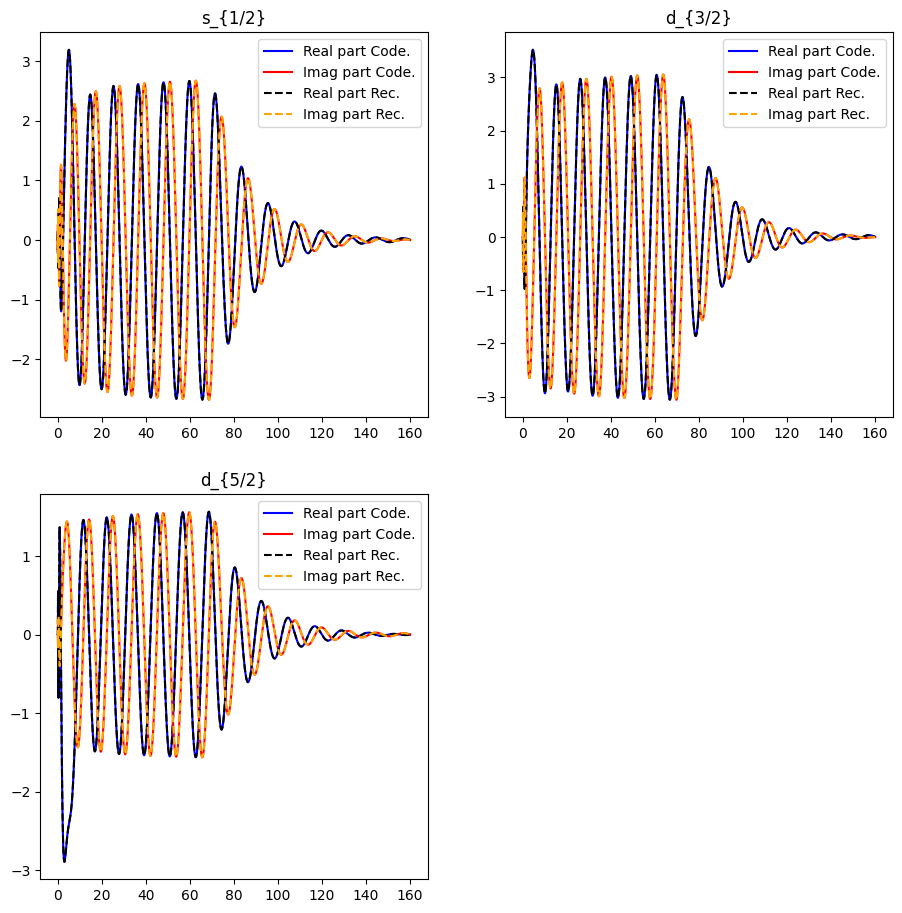

In [16]:
plt.figure(figsize=(11, 11))

plt.subplot(2, 2, 1)
plt.plot(np.real(g_grid_f_code), np.real(pw_f_9_code_s1), "-", color="blue", label="Real part Code.")
plt.plot(np.real(g_grid_f_code), np.imag(pw_f_9_code_s1), "-", color="red", label="Imag part Code.")
plt.plot(np.real(g_grid_f), np.real(pw_f_9_s1), "--", color="black", label="Real part Rec.")
plt.plot(np.real(g_grid_f), np.imag(pw_f_9_s1), "--", color="orange", label="Imag part Rec.")
plt.legend()
plt.title("s_{1/2}")

plt.subplot(2, 2, 2)
plt.plot(np.real(g_grid_f_code), np.real(pw_f_9_code_d3), "-", color="blue", label="Real part Code.")
plt.plot(np.real(g_grid_f_code), np.imag(pw_f_9_code_d3), "-", color="red", label="Imag part Code.")
plt.plot(np.real(g_grid_f), np.real(pw_f_9_d3), "--", color="black", label="Real part Rec.")
plt.plot(np.real(g_grid_f), np.imag(pw_f_9_d3), "--", color="orange", label="Imag part Rec.")
plt.legend()
plt.title("d_{3/2}")

plt.subplot(2, 2, 3)
plt.plot(np.real(g_grid_f_code), np.real(pw_f_9_code_d5), "-", color="blue", label="Real part Code.")
plt.plot(np.real(g_grid_f_code), np.imag(pw_f_9_code_d5), "-", color="red", label="Imag part Code.")
plt.plot(np.real(g_grid_f), np.real(pw_f_9_d5), "--", color="black", label="Real part Rec.")
plt.plot(np.real(g_grid_f), np.imag(pw_f_9_d5), "--", color="orange", label="Imag part Rec.")
plt.legend()
plt.title("d_{5/2}")

In [17]:
file_coeffs_q_st_p3_emi = data_folder + "second_photon/wave_2ph_-2_to_-2_eF1.dat"
file_coeffs_q_st_p3_abs = data_folder + "second_photon/wave_2ph_-2_to_-2_eF2.dat"

coeffs_q_st_p3_emi_raw = np.loadtxt(file_coeffs_q_st_p3_emi)
coeffs_q_st_p3_emi_raw = coeffs_q_st_p3_emi_raw.T
coeffs_q_st_p3_emi = coeffs_q_st_p3_emi_raw[:, 0] + 1j * coeffs_q_st_p3_emi_raw[:, 1]

print(coeffs_q_st_p3_emi.shape)
print(coeffs_q_st_p3_emi)


coeffs_q_st_p3_abs_raw = np.loadtxt(file_coeffs_q_st_p3_abs)
coeffs_q_st_p3_abs_raw = coeffs_q_st_p3_abs_raw.T
coeffs_q_st_p3_abs = coeffs_q_st_p3_abs_raw[:, 0] + 1j * coeffs_q_st_p3_abs_raw[:, 1]

print(coeffs_q_st_p3_abs.shape)
print(coeffs_q_st_p3_abs)


(535,)
[ 4.81172964e-06-1.55769359e-18j  1.38044011e-04-3.21330419e-17j
  7.52760018e-04-1.88109077e-16j  1.58859011e-03-3.87927537e-16j
  2.80311142e-03-6.88902060e-16j  3.52827322e-03-8.68229100e-16j
  3.75456596e-03-9.07260378e-16j  2.63948333e-03-6.42498207e-16j
  5.85735412e-04-1.11022302e-16j -3.09295003e-03+7.70650904e-16j
 -5.44178629e-03+1.36045689e-15j -5.47401497e-03+1.26851654e-15j
  4.25913708e-04-2.24836426e-16j  6.78527697e-03-1.79327039e-15j
  9.48907860e-03-2.20483354e-15j -2.27110723e-03+1.38170725e-15j
 -1.92190161e-02+5.04284114e-15j -5.52216335e-03-1.34527806e-15j
  1.38771134e-02-5.74193471e-15j  2.27805999e-02-4.90579799e-15j
  1.97064895e-02-1.73472348e-18j  1.02645294e-02+5.55718666e-15j
 -1.24998079e-03+9.93031612e-15j -1.23252541e-02+1.23182714e-14j
 -2.15582710e-02+1.25212340e-14j -2.80848427e-02+1.02435421e-14j
 -3.15199690e-02+5.81305837e-15j -3.17598688e-02+2.44596010e-16j
 -2.90171508e-02-5.19896626e-15j -2.36858103e-02-9.93996552e-15j
 -1.63507558e-02-1

Text(0.5, 1.0, 'Coeffs Emi p3')

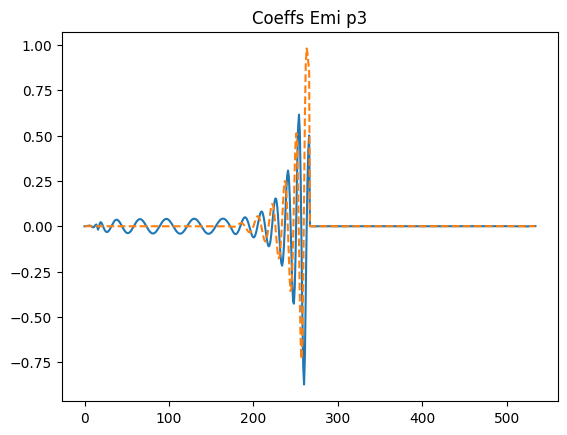

In [18]:
plt.plot(np.real(coeffs_q_st_p3_emi))
plt.plot(np.imag(coeffs_q_st_p3_emi), "--")
plt.title("Coeffs Emi p3")

(260.0, 270.0)

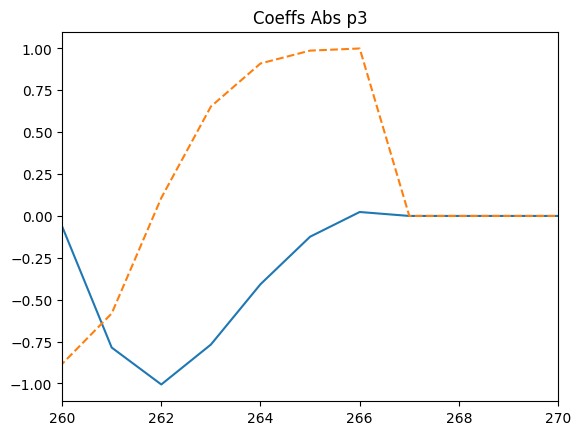

In [19]:
plt.plot(np.real(coeffs_q_st_p3_abs))
plt.plot(np.imag(coeffs_q_st_p3_abs), "--")
plt.title("Coeffs Abs p3")
plt.xlim([260, 270])

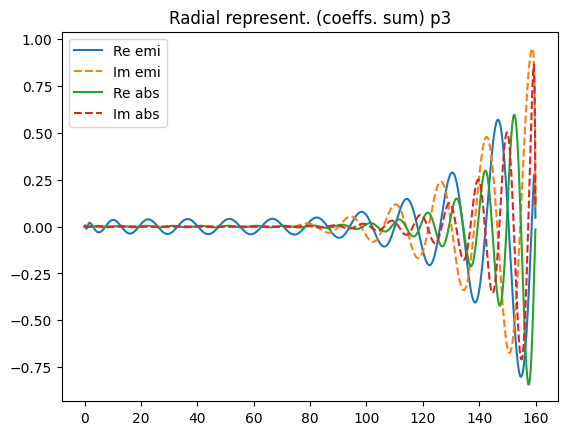

In [20]:
# limit the large component by 267 (as in the large component after 1ph)
n_limit = 267

q_st_p3_emi = getfunc_in_r(n_knots_f, k_order_f, knots_f, coeffs_q_st_p3_emi[:n_limit], g_grid_f)
q_st_p3_abs = getfunc_in_r(n_knots_f, k_order_f, knots_f, coeffs_q_st_p3_abs[:n_limit], g_grid_f)

plt.plot(np.real(g_grid_f), np.real(q_st_p3_emi), label="Re emi")
plt.plot(np.real(g_grid_f), np.imag(q_st_p3_emi), "--",  label="Im emi")
plt.plot(np.real(g_grid_f), np.real(q_st_p3_abs), label="Re abs")
plt.plot(np.real(g_grid_f), np.imag(q_st_p3_abs), "--",  label="Im abs")
plt.title("Radial represent. (coeffs. sum) p3")
plt.legend()

In [21]:
file_coeffs_q_st_s1_emi = data_folder + "second_photon/wave_2ph_-2_to_1_eF1.dat"
file_coeffs_q_st_s1_abs = data_folder + "second_photon/wave_2ph_-2_to_1_eF2.dat"

coeffs_q_st_s1_emi_raw = np.loadtxt(file_coeffs_q_st_s1_emi)
coeffs_q_st_s1_emi_raw = coeffs_q_st_s1_emi_raw.T
coeffs_q_st_s1_emi = coeffs_q_st_s1_emi_raw[:, 0] + 1j * coeffs_q_st_s1_emi_raw[:, 1]

print(coeffs_q_st_s1_emi.shape)
print(coeffs_q_st_s1_emi)


coeffs_q_st_s1_abs_raw = np.loadtxt(file_coeffs_q_st_s1_abs)
coeffs_q_st_s1_abs_raw = coeffs_q_st_s1_abs_raw.T
coeffs_q_st_s1_abs = coeffs_q_st_s1_abs_raw[:, 0] + 1j * coeffs_q_st_s1_abs_raw[:, 1]

print(coeffs_q_st_s1_abs.shape)
print(coeffs_q_st_s1_abs)


(535,)
[ 1.62204214e-04+2.38212770e-16j  5.09025229e-04+1.23159946e-15j
  1.39540009e-03+2.32832417e-15j  2.23501357e-03+4.90666535e-15j
  3.28072498e-03+5.86943688e-15j  3.53303454e-03+7.50983477e-15j
  3.10439706e-03+5.42881712e-15j  1.41848360e-03+3.75513422e-15j
 -1.04135671e-03-3.33413852e-15j -4.32339441e-03-6.70860936e-15j
 -5.50393732e-03-1.31435661e-14j -3.68370610e-03-4.23012320e-15j
  2.97746317e-03+1.71412363e-15j  8.02483659e-03+2.07698442e-14j
  7.48960612e-03+8.88481996e-15j -7.01157247e-03-2.37830589e-15j
 -1.79800635e-02-5.54140067e-14j  1.58722170e-03+3.09423711e-14j
  1.79123229e-02+1.56992475e-15j  2.16891522e-02+6.35082265e-14j
  1.35608312e-02-1.30225691e-14j  1.81562218e-03+2.47785733e-14j
 -1.02908534e-02+2.21498167e-14j -2.02568498e-02-7.96758493e-15j
 -2.74789981e-02+2.55108434e-14j -3.12762572e-02-1.91027749e-14j
 -3.17733890e-02+1.67921232e-14j -2.90736504e-02-2.76480228e-14j
 -2.37185729e-02-5.83560977e-15j -1.62599158e-02-1.98001338e-14j
 -7.45800639e-03-2

Text(0.5, 1.0, 'Coeffs Emi s1')

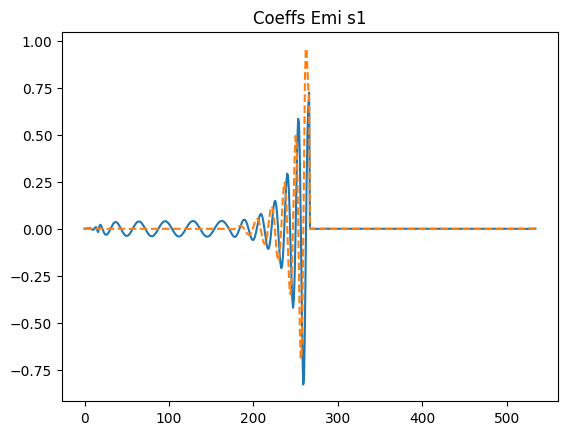

In [22]:
plt.plot(np.real(coeffs_q_st_s1_emi))
plt.plot(np.imag(coeffs_q_st_s1_emi), "--")
plt.title("Coeffs Emi s1")

Text(0.5, 1.0, 'Coeffs Abs s1')

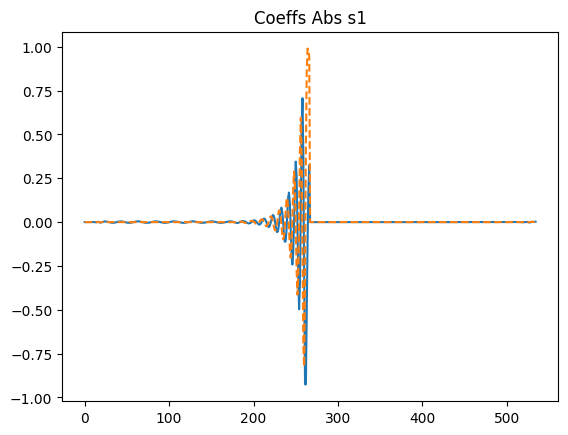

In [23]:
plt.plot(np.real(coeffs_q_st_s1_abs))
plt.plot(np.imag(coeffs_q_st_s1_abs), "--")
plt.title("Coeffs Abs s1")

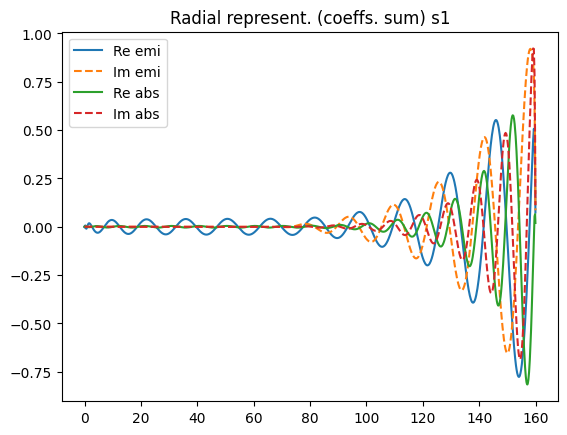

In [ ]:
# limit the large component by 267 (as in the large component after 1ph)
n_limit = 267

q_st_s1_emi = getfunc_in_r(n_knots_f, k_order_f, knots_f, coeffs_q_st_s1_emi[:n_limit], g_grid_f)
q_st_s1_abs = getfunc_in_r(n_knots_f, k_order_f, knots_f, coeffs_q_st_s1_abs[:n_limit], g_grid_f)

plt.plot(np.real(g_grid_f), np.real(q_st_s1_emi), label="Re emi")
plt.plot(np.real(g_grid_f), np.imag(q_st_s1_emi), "--",  label="Im emi")
plt.plot(np.real(g_grid_f), np.real(q_st_s1_abs), label="Re abs")
plt.plot(np.real(g_grid_f), np.imag(q_st_s1_abs), "--",  label="Im abs")
plt.title("Radial represent. (coeffs. sum) s1")
plt.legend()

In [25]:
# NOTE: for now consider the last energy point (9)
omega_1ph = 0.519773 # a.u.
omega_2ph = 0.056961 # a.u.
eigval_p3 = -0.3950057030

In [26]:
# Integration part p_{3/2} -> d-{3/2} -> p_{3/2} Emission, last energy point (9)
l1 = 2.0
l2 = 1.0
eps1 = eigval_p3 + omega_1ph
eps2 = eigval_p3 + omega_1ph - omega_2ph

print('l1=',l1,'e1=',np.round(eps1,4),'l2=',l2,\
    'e2=',np.round(eps2,4),)

#Integrate only large component f
idx_d3 = 1
f = coeffs_pw_f_9_real[:, idx_d3] + 1j * coeffs_pw_f_9_imag[:, idx_d3]
i = 50
while(np.imag(knots_f[i])<0.000001):
    #print(" checking amplitude and phase in",np.real(tf[i]))
#   from the perturbed wf get amplitude and phase
    amp, ph = getamp_and_phase(n_knots_f, k_order_f, knots_f, f, eps1, l1, knots_f[i])
#    anaint=analytint(eps1,eps2,tf[i],l1,l2,amp,ph,1)    
    numint = numericalint(f, q_st_p3_emi, g_grid_f, g_weights_f, knots_f, n_knots_f, k_order_f, l2, eps2, knots_f[i], 1, g_num_between_f) 
    anaint = analytint(eps1, eps2, knots_f[i], l1, l2, amp, ph, 1)
    print('f: in',np.real(knots_f[i]),'A=',np.round(amp,2),' phase=',np.round(ph,3), \
        ' M=',np.round(numint,1), '+', \
         np.round(anaint,1),'=',np.round(anaint+numint,2))
    i=i+10

l1= 2.0 e1= 0.1248 l2= 1.0 e2= 0.0678


KeyboardInterrupt: 

Text(0.5, 1.0, 'Phase')

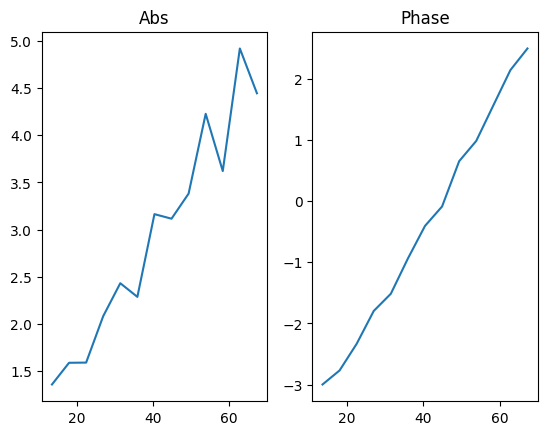

In [ ]:
bp_used = [
    13.54545455, 
    18.02597403, 
    22.50649351, 
    26.98701299, 
    31.46753247, 
    35.94805195, 
    40.42857143, 
    44.90909091,
    49.38961039,
    53.87012987,
    58.35064935,
    62.83116883,
    67.31168831
]

M_elems_comp = np.array([
    265.88 + 1j * 150.14,
    262.83 + 1j * 241.79,
    136.45 + 1j * 330.52,
    -68.01 + 1j * 463.51,
    -226.39 + 1j * 498.02,
    -433.89 + 1j * 276.47,
    -711.51 + 1j * 25.08,
    -673.26 - 1j * 195.58,
    -396.37 - 1j * 649.64,
    -204.35 - 1j * 929.26,
    290 - 1j * 761.45,
    895.55 - 1j * 651.49,
    962.83 - 1j * 271.98
])

M_elem_true = -209.66841030907096 - 1j * 81.791984574094357

plt.subplot(1, 2, 1)
plt.plot(bp_used, np.abs(M_elems_comp / M_elem_true))
plt.title("Abs")

plt.subplot(1, 2, 2)
plt.plot(bp_used, np.angle(M_elems_comp / M_elem_true))
plt.title("Phase")